# Cluster Sentences: blablabla

This notebook looks into techniques for defining clusters.
- First, sentences duplicates with a cosine similarity score of >=1 are removed.
- Compare resulting clusters of two lemmatisation methods (nltk, spacy, no lemma).
- Visualize clusters

### Settings

In [ ]:
# Settings
embedding_file = "embedding_corpus_free_3600_250606.pickle"
# embedding_file = "embeddings used for comparing lemma/RAW_df_xml2corpus_by_sentence_pmid_free_3600_250606.pickle"
similarity_file = "similarity_corpus_free_3600_250606.pickle"

raw_corpus_file = "corpus_free_3600_250606.csv"
meta_file = 'meta_free_3600_250606.csv'

# used_st_model = "NeuML/pubmedbert-base-embeddings"

path_to_write_dict = '../../data/vectors/duplets'
path_to_save_fig = '../../data/graphs'
experiment_name = "_".join(embedding_file.split(".")[0].split("_")[2:])

# files for comparing lemmatisation methods
# Multiple vector files
folder = "explore_vectors"
filename0 = 'RAW_df_xml2corpus_by_sentence_pmid_free_3600_250606.pickle'
filename3 = 'no_lemma_applied_df_xml2corpus_by_sentence_pmid_free_3600_250606.pickle'
filename2 = 'nltk_df_xml2corpus_by_sentence_pmid_free_3600_250606.pickle'
filename1 = 'spacy_df_xml2corpus_by_sentence_pmid_free_3600_250606.pickle'

files = [filename0, filename1, filename2, filename3]

## Initialisation

### Import and functions

In [ ]:
# import
from pathlib import Path
import inspect
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib_venn import venn3
import matplotlib.pyplot as plt
import torch
from sentence_transformers import util


# https://amueller.github.io/word_cloud/
from wordcloud import WordCloud
from wordcloud import STOPWORDS

from sklearn.decomposition import PCA
from umap import UMAP

### Functions

In [ ]:
def get_duplets_dataframe(similarity_matrix, threshold: float = 1.0):
    """Return a similarity dataframe that only contains duplets, where duplets are defined as sentences with a similarity score equal or higher than provided threshold."""
    # Substract 2 from the cosine similarity score that matched itself, so that it turns the value to -1.
    df_duplets = pd.DataFrame(
        np.subtract(
            similarity_matrix, 
            np.identity(similarity_matrix.shape[0]) *2
        )
    )

    # Drop columns and rows without duplets (defined by the threshold)
    df_duplets = df_duplets[df_duplets >= threshold].dropna(axis=0, how='all')
    df_duplets = df_duplets[df_duplets >= threshold].dropna(axis=1, how='all')

    # if df_duplets is empty (and therefore there are no duplets)
    if len(df_duplets.index) == 0:
        # raise an error
        raise ValueError("No duplets found in provided pd.DataFrame!")

    return df_duplets

def get_duplets_clusters(df_duplets):
    """Return a dictionary where the kept 'unique sentence index' (=key) references to the duplet index in a list (=values)."""
    # Create a dict with indexes on sentences with a duplet.
    potential_duplets = df_duplets.index
    duplet_dict = dict()

    # Iterate over potential duplets list
    # TODO: There should be a nicer way with groupby or something
    while len(potential_duplets) != 0:
        
        # Look at first item
        idx = potential_duplets[0]

        # For idx in list, find other idx that have same sentence.
        cluster = df_duplets.loc[idx, ~df_duplets.loc[idx].isna()].index

        # Store 'unique' idx in as key, and store 'duplet' idx as values
        duplet_dict[idx] = cluster.to_list()

        # Remove duplet index and first item from potential_duplets. (This will shorten the loop)
        potential_duplets = potential_duplets[~potential_duplets.isin(cluster)]
        potential_duplets = potential_duplets[1:]

    return duplet_dict

def delete_for_torch_tensor(x: torch.Tensor, row_exclude, axis: int = 0):
    """Return a new torch.Tensor with sub-arrays along an axis deleted.
    
    Parameters:
        x (torch.Tensor): Input tensor.

        row_exclude (list) : slice, array-like of ints or bools
        Indicate indices of sub-arrays to remove along the specified axis.

        axis (int): default = 0
        The axis along which to delete the subarray defined by row_exclude. 
    """
    # get indexes of interest (all indexes - indexes to remove)
    all_indexes = np.arange(x.shape[axis])
    indexes_of_interest = np.delete(all_indexes, row_exclude)

    # select rows and columns of interest (thus removing `indexes to remove`)
    if axis == 0:
        x = x[indexes_of_interest]
    if axis == 1:
        x = x[:, indexes_of_interest]
    
    return x

def plot_clusters(embed, df_vector_labels, column):
    # get unique colours
    colours = sns.color_palette("nipy_spectral", df_vector_labels[column].nunique())

    for idx, val in enumerate(df_vector_labels[column].unique()):
        projection = embed[df_vector_labels[column] == val]
        plt.scatter(projection.T[0], projection.T[1], alpha=0.1, c=colours[idx], label= val)
    plt.title(f"Coloured by {column}")

# For normalizing the vectors:
# function of getting magnitude/length/norm
def get_length(matrix):
    """Calculate the length of a vector"""
    length = np.sqrt(
        np.sum(
            np.power(
                matrix, 
                2
            ),
            axis=1
        )
    )

    return length

# function to divide vector by length
# (..probably there is a numpy function for it.. but i failed to find it)
def normalize(matrix, scales):
    """Divide elements in matrix by given scale"""
    return np.array([vector / scales[idx] for idx, vector in enumerate(matrix)])

def create_wordcloud(sentences: list, stopwords: list, verbose: bool = True):
    """Create WordCloud object, 16:9 ratio, top 100 words."""
    # Print general info
    if verbose:
        print(f"Number of sentences in wordcloud: {len(sentences)}")

    # Remove stopwords
    if len(stopwords) != 0:
        new_sentences = []
        for sent in sentences:
            for word in stopwords:
                sent = sent.replace(word, "")
            new_sentences.append(sent)
    else:
        new_sentences = sentences

    # Create WordCloud object, 16:9 ratio, top 100 words
    wordcloud = WordCloud(
        width=1600,
        height=900,
        max_words= 100,
        stopwords= STOPWORDS,
        colormap= 'PiYG'
    ).generate(" ".join(new_sentences)) # join words to form one long 'sentence'

    # Plot
    plt.imshow(wordcloud)
    plt.axis('off')


### Load

In [ ]:
# Load raw corpus
df_corpus = pd.read_csv(f'../../data/corpus/{raw_corpus_file}')

# Load metadata
df_meta = pd.read_csv(f'../../data/meta/{meta_file}', index_col=0)


# Load cosine similarity scores
with open(f"../../data/vectors/{similarity_file}", 'rb') as handle:
    similarities = pickle.load(handle)

# Load sentence embeddings
with open(f"../../data/vectors/{embedding_file}", 'rb') as handle:
    embeddings = pickle.load(handle)

# Corresponding vector_ids (key between matrixes and df_corpus)
vector_ids = np.arange(embeddings.shape[0])

In [ ]:
# Check if embeddings normalized,
# if not, it will be normalized:
if np.sum(get_length(embeddings)) == embeddings.shape[0]:
    print("Embedding is already normalized. (`normalized_embeddings == embeddings`)")
    normalized_embeddings = embeddings

else:
    print("Embedding is not normalized yet.")
    print("Applying normalization.")
    normalized_embeddings = normalize(
        embeddings,
        get_length(
            embeddings
        )
    )
    print("Normalized embedding successful created. (`normalized_embeddings != embeddings`)")

In [ ]:
# Check if similarity score is loaded correctly
if np.sum(np.array(similarities.diagonal())) == embeddings.shape[0]:
    print("Similarity scores appear to be correctly loaded.")

else:
    raise ValueError(f"Something went wrong with loading the similarity scores? The sum of the diagonal appears not to be the same as the total number of rows. Sum = {np.sum(np.array(similarities.diagonal()))}, number of rows = {embeddings.shape[0]} (Could be a float point error?)")

In [ ]:
# sample
similarities[:5, :5]

Similarity scores are correctly loaded if row and column indexes with the same number == `1`

In [ ]:
embeddings.shape

In [ ]:
similarities.shape

## Remove duplets (So that one unique remains)

As noted in notebook `sentence_pairs.ipynb`, there are multiple duplicated sentences. 
For clustering I would like to remove these duplicates, since we are interested in sentence similarities, I think that the 'high similarity' duplicate sentences have may influence the formation of clusters.

### Visualisation of duplets

In [ ]:
# Visualize clusters of duplets
sns.clustermap(get_duplets_dataframe(similarities).fillna(0))

### Remove duplets from `embeddings` and `similarities`

NOTE: From what I see in the cluster formation parts.. It did not really made a difference to remove the duplets:

Before removing duplets:

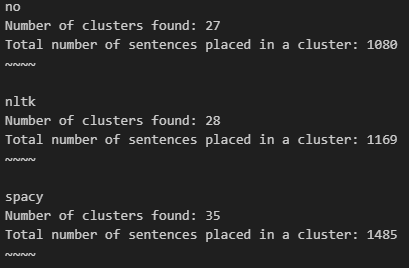

After removing duplets:

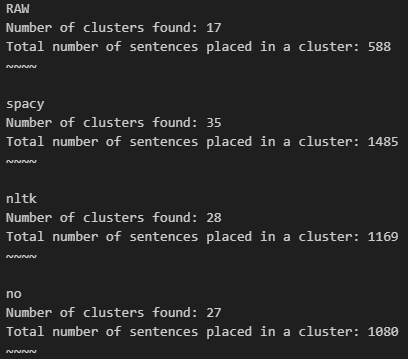

The removed duplets are registered in a dictionary that is written to `path_to_write_dict`, where the first occurance of the sentence is kept (=key in dict) and removed indexes are listed (as values in dict).

First occurrence is saved. The rest will be removed. (This will automatically shorten the list)
I cannot think of a reason why it would matter which sentence would be removed.

In [ ]:
# Get duplet dictionary
duplet_dict = get_duplets_clusters(
    get_duplets_dataframe(
        similarities
    )
)

# Create a list with indexes on sentences with a duplet.
duplet_to_remove = [item for layer in duplet_dict.values() for item in layer]
print(f"Number of indexes to remove: {len(duplet_to_remove)}")

# get indexes of interest (all indexes - indexes to remove)
all_indexes = np.arange(embeddings.shape[0])
vector_ids = np.delete(all_indexes, duplet_to_remove)

# Drop duplets from `embeddings` (rows only)
print(f"Embedding shape with duplets: {embeddings.shape}")
embeddings = np.delete(embeddings, duplet_to_remove, 0)
normalized_embeddings = np.delete(normalized_embeddings, duplet_to_remove, 0)
print(f"Embedding shape without duplets: {embeddings.shape}")

# Drop duplets from `similarity` (both rows and columns)
print(f"Similarities shape with duplets: {similarities.shape}")
similarities = delete_for_torch_tensor(similarities, duplet_to_remove, axis=0)
similarities = delete_for_torch_tensor(similarities, duplet_to_remove, axis=1)
print(f"Similarities shape without duplets: {similarities.shape}")


In [ ]:
# Check if duplets are gone:
try:
    get_duplets_dataframe(
        similarities
    )
    print('We have a problem.. Duplets are still present..')

except ValueError:
    print("No duplets found in matrix.")

In [ ]:
# Save `duplet_dict` as .csv
# (This is important, because if the 'duplet' is a hit, we need to find it back in the corpus. Also if the hit occurs multiple times in the corpus.)

# Create `duplets` directory, if it does not yet exists.
Path(path_to_write_dict).mkdir(exist_ok = True)

# Save dict
with open(f"{path_to_write_dict}/dict_{'_'.join(embedding_file.split('_')[2:])}", "wb") as handle:
    pickle.dump(embeddings, handle)

## Compare outcome of different pre-processing methods

Comparison:
- RAW no lowercase and punctuations, 
- no lemma, 
- spacy lemmatization, 
- nltk lemmatization

### Method proposed by SBERT

Mainly used code from (suggested by SBERTs documentation):
https://github.com/UKPLab/sentence-transformers/blob/master/examples/sentence_transformer/applications/clustering/fast_clustering.py

`util.community_detection` is based on cosine similarity scores. It clusters sentences that have high (= x >= user_defined_threshold) cos_sim with eachother.

#### Quick look at the source code:

It computes the cosine similarity scores 
- then per row (=sentence) it counts the frequency of how often the cosine similarity that is above the user defined threshold (incl. the threshold. x >= threshold).
- then checks if this count is higher than the user defined min_community_size
- then looks at the largest count is and returns the indices of these rows (=sentences) 
- then it removes duplicate clusters (the previous code does not check if it is doing extra work.)

In [ ]:
print(inspect.getsource(util.community_detection))

#### Continue detection:

In [ ]:
# Load vectors
vectors = {}
for file in files:
    with open(f"../../data/vectors/embeddings used for comparing lemma/{file}", 'rb') as handle:
        embeddings = pickle.load(handle)
        vectors[file.split("_")[0]] = embeddings

In [ ]:
# Detect clusters

# Two parameters to tune:
# min_cluster_size: Only consider cluster that have at least 25 elements
# threshold: Consider sentence pairs with a cosine-similarity larger than threshold as similar
clusters = {}
for k, vec in vectors.items():
    clusters[k] = util.community_detection(vec, min_community_size=25, threshold=0.75)

In [ ]:
# TODO: turn following metrics into a dataframe?
# TODO: Number of sentences per cluster? (make a visualisation?)
# Number of clusters per lemma*
for k in clusters.keys():
    print(f"{k}")
    print(f"Number of clusters found: {len(clusters[k])}")
    print(f"Total number of sentences placed in a cluster: {len([e for el in clusters[k] for e in el])}")
    print("~~~~\n")

#### Cluster set visualisation

In [ ]:
# Which sentences are there in the first cluster of the three lemma* vectors?
# use a venn diagram
first_clusters = {k: set(clusters[k][0]) for k in clusters.keys()}

In [ ]:
# clusters
venn3(
    list(first_clusters.values())[1:],
    set_labels= list(first_clusters.keys())[1:]
)
plt.title("Sentences sets of the different lemmatisation methods\nof only the first cluster.")
plt.show()

The largest cluster in `spacy` appears to be a different topic than that of `nltk` and `no lemma`.
Maybe the second largest cluster of `spacy` is the same topic?

In [ ]:
# clusters
# plt.style.use('tableau-colorblind10')
venn3(
    [
        set(clusters["spacy"][1]),
        set(clusters["nltk"][0]),
        set(clusters["no"][0]),
    ],
    set_labels= list(first_clusters.keys())[1:]
)
plt.title("Sentences sets of the different lemmatization methods\nof various clusters (see code).")
plt.show()

Above the second largest topic of `spacy` is plotted with the largest topics of `no lemma` and `nltk`. Now there is a noticable overlap in found topic. This makes me wonder what the topic is of the largest cluster for `spacy`.

In [ ]:
# Number of sentences per cluster
len(set(clusters["no"][0]))

In [ ]:
len(set(clusters["nltk"][0]))

In [ ]:
len(set(clusters["spacy"][1]))

In [ ]:
# clusters
# plt.style.use('tableau-colorblind10')
venn3(
    [
        set(clusters["spacy"][0]),
        set(clusters["nltk"][1]),
        set(clusters["no"][1]),
    ],
    set_labels= list(first_clusters.keys())[1:]
)
plt.title("Sentences sets of the different lemmatisation methods\nof various clusters (see code).")
plt.show()

#### Samples from clusters

In [ ]:
# 'RAW'
selected_cluster = clusters['RAW']

print(f"Number of clusters: {len(selected_cluster)}\n")

# Print for all clusters the top 3 and bottom 3 elements
for i, clust in enumerate(selected_cluster):
    print(f"\nCluster {i + 1}, total number of sentences: {len(clust)}")
    for sentence_id in clust[0:3]:
        print("\t", df_corpus.loc[sentence_id, 'sentence_text'])
    print("\t", "...")
    for sentence_id in clust[-3:]:
        print("\t", df_corpus.loc[sentence_id, 'sentence_text'])

In [ ]:
# 'no'
selected_cluster = clusters['no']

print(f"Number of clusters: {len(selected_cluster)}\n")

# Print for all clusters the top 3 and bottom 3 elements
for i, clust in enumerate(selected_cluster):
    print(f"\nCluster {i + 1}, total number of sentences: {len(clust)}")
    for sentence_id in clust[0:3]:
        print("\t", df_corpus.loc[sentence_id, 'sentence_text'])
    print("\t", "...")
    for sentence_id in clust[-3:]:
        print("\t", df_corpus.loc[sentence_id, 'sentence_text'])

In [ ]:
# 'nltk'
selected_cluster = clusters['nltk']

print(f"Number of clusters: {len(selected_cluster)}\n")

# Print for all clusters the top 3 and bottom 3 elements
for i, clust in enumerate(selected_cluster):
    print(f"\nCluster {i + 1}, total number of sentences: {len(clust)}")
    for sentence_id in clust[0:3]:
        print("\t", df_corpus.loc[sentence_id, 'sentence_text'])
    print("\t", "...")
    for sentence_id in clust[-3:]:
        print("\t", df_corpus.loc[sentence_id, 'sentence_text'])

In [ ]:
# 'spacy'
selected_cluster = clusters['spacy']

print(f"Number of clusters: {len(selected_cluster)}\n")

# Print for all clusters the top 3 and bottom 3 elements
for i, clust in enumerate(selected_cluster):
    print(f"\nCluster {i + 1}, total number of sentences: {len(clust)}")
    for sentence_id in clust[0:3]:
        print("\t", df_corpus.loc[sentence_id, 'sentence_text'])
    print("\t", "...")
    for sentence_id in clust[-3:]:
        print("\t", df_corpus.loc[sentence_id, 'sentence_text'])

## Prepare a filter (df_vector_labels)

In [ ]:
# Create df_vector_labels (Later used for catching clusters identifiers)
df_vector_labels = pd.DataFrame({'vector_id': vector_ids})
df_vector_labels.tail()

In [ ]:
# Join sentences and pmid
df_vector_labels = df_vector_labels.join(
    df_corpus[['sentence_text', 'paper_name']].rename(columns= {'paper_name': 'pmid'}),
    on='vector_id',
    how='left'
)
df_vector_labels.tail()

In [ ]:
# Replace " PD " with " parkinson disease ". (Important for generating a wordcloud)
df_vector_labels["sentence_text"] = df_vector_labels["sentence_text"].str.replace(
    "PD",
    "parkinson's disease",
    case= True
)

In [ ]:
# Join metadata of paper
df_vector_labels = df_vector_labels.join(
    df_meta[['pmid', 'is_accepted', 'is_published', 'is_retracted', 'pub_year', 'cited_by_count', 'referenced_count']].set_index('pmid'),
    on='pmid'
)
df_vector_labels.tail()

## Clustering

...What do these clusters even mean?

### With SBERT util

In [ ]:
clusters = util.community_detection(embeddings, min_community_size=25, threshold=0.75)

In [ ]:
all_sentences = [vec for clique in clusters for vec in clique]
print(f"Number of clusters found: {len(clusters)}")
print(f"{round(len(all_sentences)/embeddings.shape[0] * 100, 2)}% ({len(all_sentences)}/{embeddings.shape[0]}) sentences are placed in a cluster.")

#### Add column `community` to df_vector_labels

In [ ]:
# Add column with `cluster_id` (cluster_id == -1 when it's not assigned to a clusters)
# NOTE: The key in this case is the index of the list, since the index may have changed when removing duplicates.
df_vector_labels["community_SBERT"] = -1
for idx, clique in enumerate(clusters):
    df_vector_labels.loc[df_vector_labels.index.isin(clique), 'community_SBERT'] = idx

In [ ]:
df_vector_labels.head()

### Other cluster method .......

## Cluster visualisation

### Word cloud

In [ ]:
# Create folder for wordclouds
path_to_wordcloud = "/".join([path_to_save_fig, experiment_name, "wordclouds"])
Path(path_to_wordcloud).mkdir(exist_ok = True)
print(f"Graphs will be saved in: '{path_to_wordcloud}'")

In [ ]:
# Plot and save wordcloud per SBERT cluster
for cluster_id in df_vector_labels['community_SBERT'].unique():

    # Select column 'sentence_text' on given cluster_id
    sentences = df_vector_labels.loc[
                df_vector_labels['community_SBERT'] == cluster_id,
                'sentence_text'
            ].values

    # Plot wordcloud
    create_wordcloud(
        sentences= sentences,
        stopwords= ["parkinson's disease", "pesticides", "parkinson", "disease", "pesticide", ]
    )

    # Add title, save and show figure
    plt.title(f"SBERT cluster: {cluster_id}\nTotal number of sentences: {len(sentences)}")
    plt.savefig("/".join([path_to_save_fig, experiment_name, "wordclouds", f"SBERT_cluster_{cluster_id}.png"]))
    plt.show()

### Similarity statistics

In [ ]:
# TODO: Have a look at the similatity scores within the clusters.

### Plot graph

#### PCA

In [ ]:
# Apply PCA
pca = PCA(n_components=2)
pca_embeddings = pca.fit_transform(normalized_embeddings)
# pca_embeddings = pca.fit_transform(embeddings)
pca_embeddings[:5]

In [ ]:
df_vector_labels.columns

In [ ]:
plot_clusters(
    pca_embeddings, 
    df_vector_labels, 
    'community_SBERT'
    # 'pub_year'
)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
plt.show()

#### UMAP

In [ ]:
# NOTE: Takes some time... (~1 minute)

umap = UMAP(
        n_components= 2,
        n_neighbors= int(normalized_embeddings.shape[0] * (1/32)),
        # min_dist= 0.0, # only influences projection
        metric= "cosine",
    )
umap_embeddings = umap.fit_transform(normalized_embeddings)
# umap_embeddings = umap.fit_transform(embeddings)

In [ ]:
plt.scatter(umap_embeddings.T[0], umap_embeddings.T[1], alpha=0.1)

In [ ]:
df_vector_labels.columns

In [ ]:
plot_clusters(
    umap_embeddings,
    df_vector_labels,
    'community_SBERT'
    # 'pub_year'
    # 'pmid'
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.show()

## Graph

In [ ]:
df_vector_labels.head()

In [ ]:
# https://bdpedigo.github.io/networks-course/plot_large.html

# from graspologic.plot import networkplot
    # node_df["x"] = umap_embedding.T[0]
    # node_df["y"] = umap_embedding.T[1]

    # # Create a dictionary where each cluster_id gets an unique colour.
    # colours = sns.color_palette("nipy_spectral", df_vector_labels['community'].nunique())
    # palette = dict(zip(df_vector_labels['community'].unique(), colours))

    # # Plot graph
    # ax = networkplot(
    #     adj,
    #     node_data=node_df,
    #     x="x",
    #     y="y",
    #     node_size="rank_strength",
    #     node_sizes=(10, 80),
    #     node_hue="community",

    #     edge_linewidth=0.3,
    #     figsize=(20, 20),
    #     palette=palette,
    #     title = f"Cosine similarity with threshold of {thres}",
    # )
    # ax.axis("off")